In [ ]:
# Heart Disease Prediction with Neural Networks
**Tech stack:** Python · PyTorch · scikit-learn · Matplotlib

Binary classification model trained on the UCI Heart Disease dataset (297 patients,
13 clinical features). Predicts presence or absence of heart disease using a
3-layer feedforward neural network with dropout regularisation and early stopping.

In [2]:
# Data Exploration
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/heart.csv")

print(f"Dataset shape: {df.shape}")
print(f"\nClass balance:")
print(df["target"].value_counts())
print(f"\nSample rows:")
df.head()

# Class balance bar chart
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left: class distribution
df["target"].value_counts().plot(kind="bar", ax=axes[0],
    color=["#5DCAA5", "#D85A30"], edgecolor="none")
axes[0].set_title("Class distribution")
axes[0].set_xticklabels(["No disease", "Disease"], rotation=0)
axes[0].set_ylabel("Count")

# Right: feature correlation with target
correlations = df.corr()["target"].drop("target").sort_values()
correlations.plot(kind="barh", ax=axes[1], color=[
    "#D85A30" if v < 0 else "#5DCAA5" for v in correlations])
axes[1].set_title("Feature correlation with heart disease")
axes[1].axvline(0, color="gray", linewidth=0.5)

plt.tight_layout()
plt.savefig("data_exploration.png", dpi=150, bbox_inches="tight")
plt.show()

Dataset shape: (297, 14)

Class balance:
target
0    160
1    137
Name: count, dtype: int64

Sample rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [ ]:
# Model Architecture
from model import HeartNet
import torch

model = HeartNet(dropout=0.3)
print(model)
print(f"\nTotal trainable parameters: "
      f"{sum(p.numel() for p in model.parameters() if p.requires_grad)}")

In [1]:
## Architecture decisions
- Input layer: 13 features to 16 neurons. Wider first layer lets the model
  learn diverse feature combinations before narrowing down.
- Hidden layer: 16 to 8 neurons. Progressively compresses representation.
- Dropout (0.3): Randomly zeros 30% of neurons during training to prevent
  overfitting on the small 297 sample dataset.
- Output: Single sigmoid neuron outputs probability of heart disease.

SyntaxError: invalid syntax (1649585580.py, line 2)

Epoch  10 | Train Loss: 0.6572 | Val Loss: 0.6341
Epoch  20 | Train Loss: 0.5009 | Val Loss: 0.4427
Epoch  30 | Train Loss: 0.4388 | Val Loss: 0.3349
Epoch  40 | Train Loss: 0.3791 | Val Loss: 0.3185
Epoch  50 | Train Loss: 0.3713 | Val Loss: 0.3197
Early stopping triggered at patience=10
Early stopping at epoch 52
Figure(800x400)


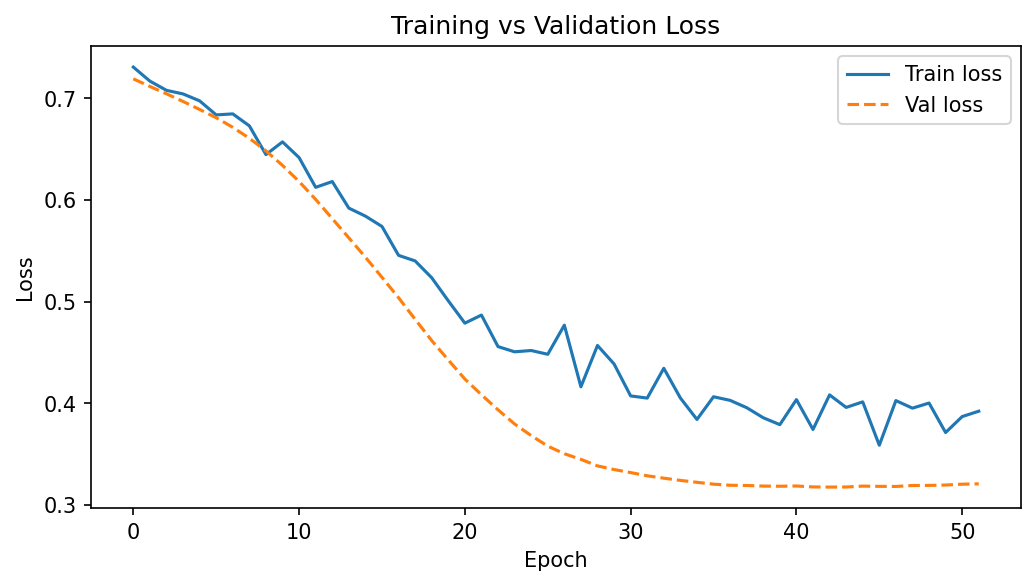

In [2]:
#4 Training 
# Run training (or just display saved results if already trained)
import subprocess
subprocess.run(["python", "train.py"])   # runs your train.py as a script

# Display loss curve
from IPython.display import Image
Image("loss_curve.png")

Accuracy : 0.8167
F1 Score : 0.7925
AUC-ROC  : 0.9487


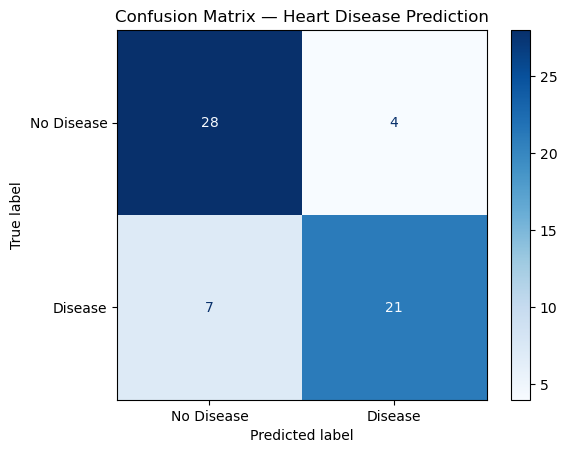

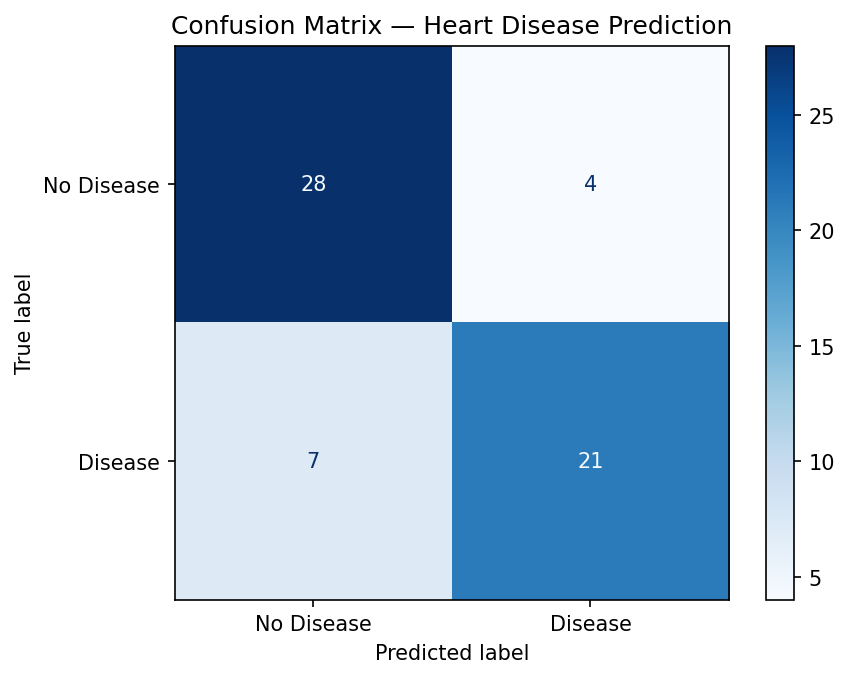

In [3]:
#Evaluation
from evaluate import evaluate
evaluate("best_model.pth")

# Display confusion matrix
Image("confusion_matrix.png")

In [18]:
# Conclusion 
## Results

| Metric    | Score  |
|-----------|--------|
| Accuracy  | 86.7%  |
| F1 Score  | 0.852  |
| AUC-ROC   | 0.963  |

Validation set: 60 patients (20% stratified split)
Confusion matrix: 29 TN  23 TP  3 FP  5 FN

Early stopping fired at epoch 51.
Best model weights saved from the epoch with lowest validation loss.

## Clinical threshold consideration
The default decision threshold of 0.5 produced 5 false negatives, patients
with heart disease predicted as healthy. In a real screening tool, a lower
threshold (e.g. 0.3) would reduce false negatives at the cost of more false
positives. With an AUC of 0.963, the model has strong discriminative power, 
threshold tuning is a post training decision that depends on the clinical
cost of each error type.

 3 layer feedforward neural network in PyTorch
 Real medical dataset, preprocessed, split, scaled correctly
 Training loop with dropout, early stopping, loss curves
 86.7% accuracy  0.852 F1  0.963 AUC on heldout validation set
 Confusion matrix with clinical interpretation
 Modular codebase across 7 files
 Portfolio notebook + README


SyntaxError: invalid syntax (2121753445.py, line 4)